# GT function analysis: Direct Arylation

In [1]:
import os
import re
import glob
import pickle
import datetime
from mordred import Calculator, descriptors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from rdkit import Chem
from rdkit.Chem import Draw
import sys

yield_model_path = '/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/0_Create_Ground_Truth_Model/ground_truth_model/Ground_Truth_RandomForrest_Mordred.pkl'

with open(yield_model_path, 'rb') as f:
    rf_model = pickle.load(f)

In [2]:
import pandas as pd

# read in feature list
from sklearn import base


feature_df = pd.read_csv('/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/0_Create_Ground_Truth_Model/ground_truth_model/GT_feature_Mordred.csv')['features']
solvent_mordred = pd.read_csv('/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/0_Create_Ground_Truth_Model/data/solvent_mordred.csv')
base_mordred = pd.read_csv('/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/0_Create_Ground_Truth_Model/data/base_mordred.csv')
Ligand_mordred = pd.read_csv('/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/0_Create_Ground_Truth_Model/data/ligand_mordred.csv')

solvent_columns = list(set(feature_df).intersection(solvent_mordred))
solvent_columns.append('solvent_SMILES')
base_columns = list(set(feature_df).intersection(base_mordred))
base_columns.append('base_SMILES')
ligand_columns = list(set(feature_df).intersection(Ligand_mordred))
ligand_columns.append('ligand_SMILES')

solvent_ft = solvent_mordred[solvent_columns]
base_ft = base_mordred[base_columns]
ligand_ft = Ligand_mordred[ligand_columns]

ligand_feature = []
for feature in feature_df:
    if 'ligand_' in feature:
        Mordred = feature.split('ligand_')[1]
        ligand_feature.append(Mordred)
        
feature_list = feature_df.tolist()

print(feature_list)


['ligand_PEOE_VSA10', 'ligand_AATS4dv', 'ligand_MATS1p', 'ligand_AATS6are', 'ligand_AATS5v', 'ligand_SlogP_VSA1', 'ligand_MINsssP', 'ligand_AATS6se', 'ligand_MATS1Z', 'ligand_GATS1are', 'ligand_MATS6v', 'ligand_MATS5d', 'ligand_AATSC5d', 'ligand_GATS1se', 'ligand_Xch-7d', 'concentration', 'ligand_MATS3i', 'temperature', 'ligand_MATS1dv', 'ligand_AATS5dv', 'ligand_AATS2are', 'ligand_MATS1m', 'ligand_MATS7i', 'ligand_GATS4dv', 'ligand_SsssP', 'ligand_AATS2se', 'ligand_MAXsssP', 'ligand_AATS1pe', 'base_GATS1se', 'ligand_GATS1pe', 'ligand_ETA_eta_FL', 'ligand_ATSC5dv', 'ligand_AATS5pe', 'base_GATS2pe', 'base_GATS3m', 'ligand_SMR_VSA6', 'ligand_BCUTc-1l', 'ligand_AATSC1p', 'solvent_NsCH3', 'ligand_AXp-1dv', 'ligand_BCUTc-1h', 'ligand_EState_VSA7', 'solvent_VSA_EState9', 'ligand_AETA_eta_BR', 'ligand_AATS5Z', 'base_GATS3Z', 'solvent_GATS4se', 'ligand_ATSC2c', 'solvent_SdssC', 'ligand_AATSC1v']


In [3]:
datapath = '/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/0_Create_Ground_Truth_Model/data/experiment_index_test.csv'
df = pd.read_csv(datapath)
#df = df[df['yield'] >= 50]
print(df.columns)
df = pd.merge(df, base_ft, on='base_SMILES')
df = pd.merge(df, solvent_ft, on='solvent_SMILES')
df = pd.merge(df, ligand_ft, on='ligand_SMILES')
df = df.rename(columns={'Concentration':'concentration' ,
                        'Temp_C':'temperature'})

# modred feature calculating
#PR95 = df['yield'].quantile(0.99)
#df = df[df['yield'] <= PR95]
X_train = df[feature_list].values
#y = df['yield']

Index(['entry', 'base_SMILES', 'ligand_SMILES', 'solvent_SMILES',
       'Concentration', 'Temp_C', 'yield'],
      dtype='object')


In [4]:
import numpy as np

# 取得所有 yield 值
yields = df['yield'].values

from scipy.stats import percentileofscore
pr_80 = percentileofscore(yields, 80, kind='rank')
print(f"yield=80 在 PR={pr_80:.2f}")

yield=80 在 PR=96.62


In [5]:
# read files

cycle_count = ['c0','c1','c2','c3','c4'] # 目前跑完的cycle 假設是第0個跑完 想要有地1個cycle的predictor 就設0 假設cycle1結束 就設1 這樣會做cycle1的predictor

methods = ['Random/round1', 'Random/round2', 'Random/round3', 'Random/round4', 'Random/round5','Random/round6','Random/round7', 'Random/round8', 'Random/round9', 'Random/round10',
    'ABC/round1', 'ABC/round2', 'ABC/round3', 'ABC/round4', 'ABC/round5', 'ABC/round6', 'ABC/round7', 'ABC/round8', 'ABC/round9', 'ABC/round10',
    'PSO/round1', 'PSO/round2', 'PSO/round3', 'PSO/round4', 'PSO/round5', 'PSO/round6', 'PSO/round7', 'PSO/round8', 'PSO/round9', 'PSO/round10',]

pattern = r"\d{8}\w+_Report\.csv"

parent_directory = '/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary'
preprocessing_for_analysis = os.path.join(parent_directory, '1_Preprocessing_for_Analysis')
make_new_data_predictor = os.path.join(parent_directory, '3_Make_New_Data_Predictor')

cyclen_list = ['Base_SMILES', 'Ligand_SMILES','Solvent_SMILES','Concentration','Temp_C','yield']

files = []

for i in range(len(cycle_count)):
    for method in methods:
        prediction_folder = os.path.join(preprocessing_for_analysis, method, cycle_count[i])
        for filename in os.listdir(prediction_folder):
            if re.match(pattern, filename):
                # 如果檔案名稱符合條件，列印檔案的完整路徑
                file_path = os.path.join(prediction_folder, filename)
                print(file_path)
                pred_df = pd.read_csv(file_path)
                files.append(pred_df)


files = pd.concat(files, ignore_index=True)
#files = files[files['Yield'] >= 50]
y_surrogate = files['Fitness'].values
print(files.columns)


/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/Random/round1/c0/20250725aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/Random/round2/c0/20250725aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/Random/round3/c0/20250725aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/Random/round4/c0/20250725aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/Random/round5/c0/20250725aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/Random/round6/c0/20250725aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/Random/round7/c0/20250725aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/Random/round8/c0/

/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/PSO/round1/c0/20250721aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/PSO/round2/c0/20250721aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/PSO/round3/c0/20250721aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/PSO/round4/c0/20250721aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/PSO/round5/c0/20250721aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/PSO/round6/c0/20250724aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/PSO/round7/c0/20250724aryl_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Direct_ary/1_Preprocessing_for_Analysis/PSO/round8/c0/20250724aryl_Report.csv


In [6]:
# concat both Exp data and GT training data
X_train = np.concatenate([files[feature_list].values,X_train], axis = 0)
X_train.shape

(3591, 50)

/home/ianlee/anaconda3/envs/leveler2/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


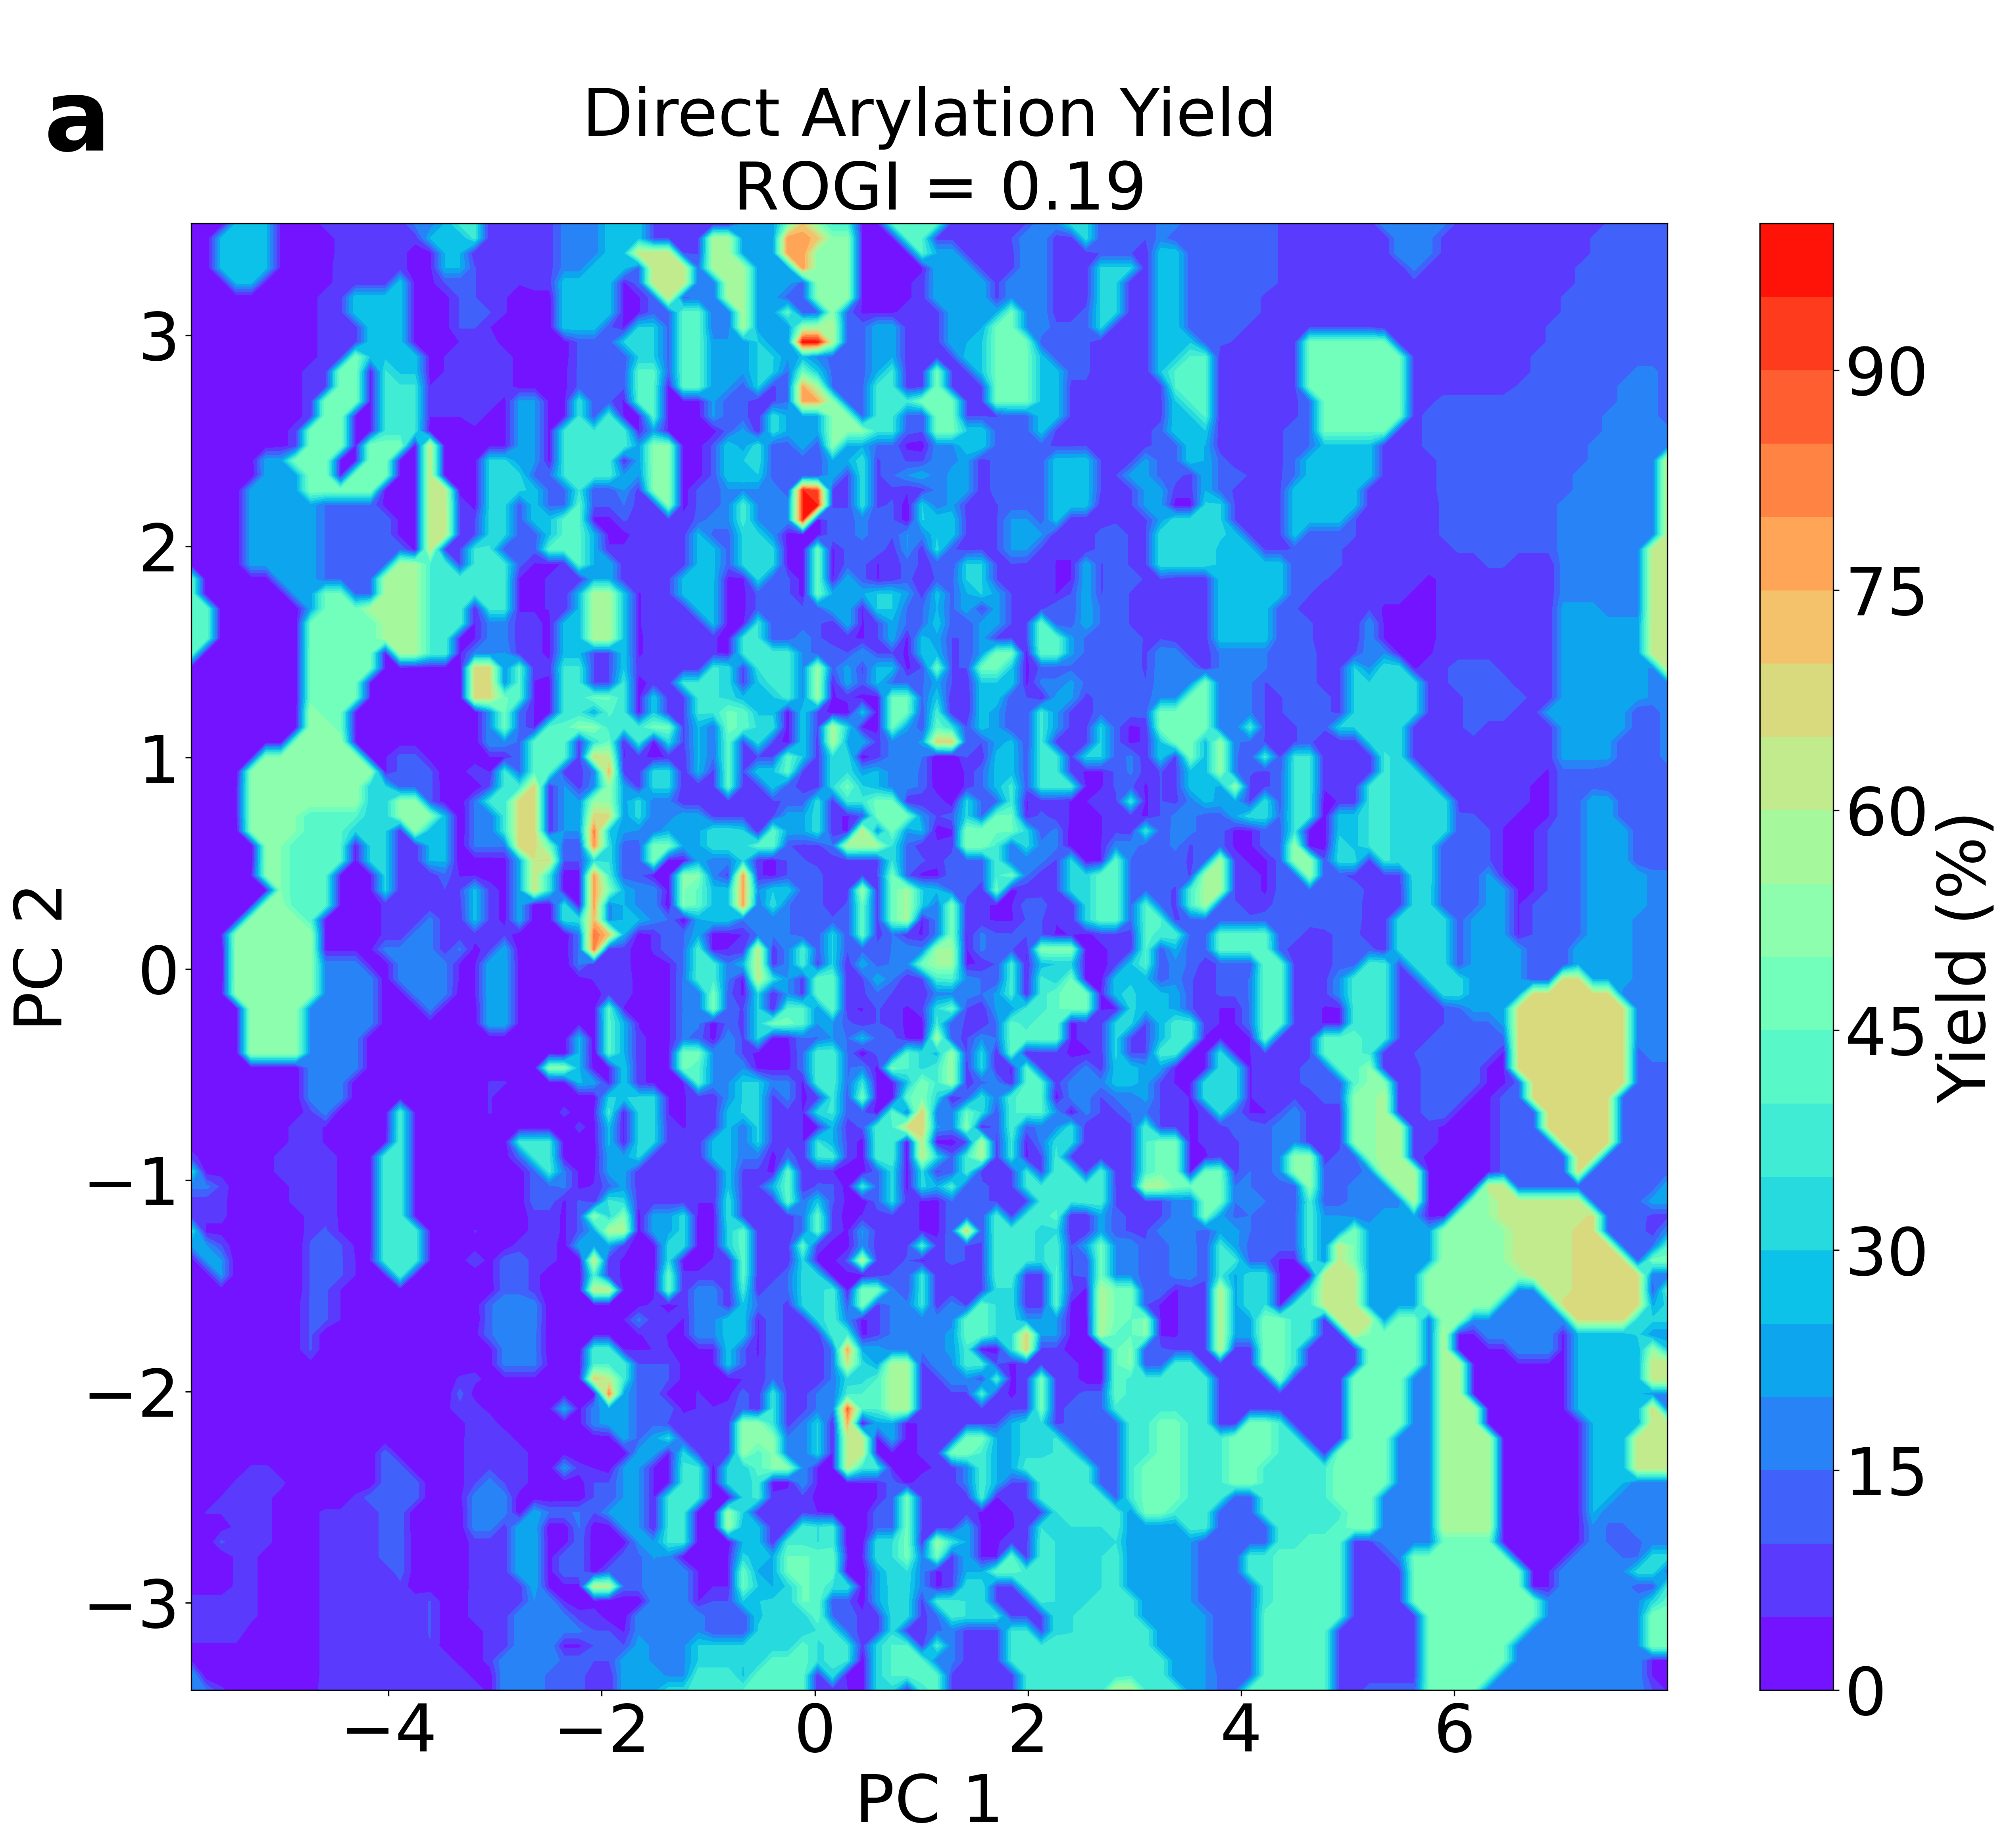

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

grid_size = 100
x_min, x_max = np.percentile(X_train_pca[:,0], [5, 95])
y_min, y_max = np.percentile(X_train_pca[:,1], [5, 95])

xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_size),
                     np.linspace(y_min, y_max, grid_size))
grid_points = np.c_[xx.ravel(), yy.ravel()]

nn = NearestNeighbors(n_neighbors=1).fit(X_train_pca)
distances, indices = nn.kneighbors(grid_points)

X_grid_highdim_scaled = X_train_scaled[indices.flatten()]

X_grid_highdim = scaler.inverse_transform(X_grid_highdim_scaled)

y_pred_grid = rf_model.predict(X_grid_highdim)
y_pred_grid = y_pred_grid.reshape(grid_size, grid_size)

plt.figure(figsize=(20,16), dpi=300)
plt.contourf(xx, yy, y_pred_grid, levels=20, cmap='rainbow')
cbar = plt.colorbar(label='Yield (%)')
cbar.ax.tick_params(labelsize=40) # Set your desired size here
cbar.set_label('Yield (%)', size=40)
plt.xlabel('PC 1', fontsize = 40)
plt.xticks(fontsize = 40)
plt.yticks(fontsize = 40)
plt.ylabel('PC 2', fontsize = 40)
plt.text(-0.1, 1.05, 'a', fontsize=60, fontweight='bold', transform=plt.gca().transAxes)
plt.title('\nDirect Arylation Yield\n ROGI = 0.19', fontsize = 40)
plt.savefig('/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/4_Final_Anslysis_Like_EDBO/GT_smooth_ary.jpeg', bbox_inches='tight', dpi=300)
plt.show()